In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# Konfiguracja urządzenia
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Urządzenie: {DEVICE}")

Urządzenie: cpu


In [5]:
# 1. Przygotowanie danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Spłaszczanie obrazka 28x28 do wektora 784
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

In [7]:
# =====================================================================
# ROZWIĄZANIE 1: Funkcja dodająca szum
# =====================================================================
def add_noise(images, noise_factor=0.3):
    """
    Dodaje losowy szum z rozkładu normalnego i przycina wartości do [0, 1].
    """
    # Generujemy szum o tym samym kształcie co wejściowe obrazy
    noise = torch.randn_like(images) * noise_factor
    
    # Dodajemy szum do obrazów
    noisy_images = images + noise
    
    # Utrzymujemy wartości pikseli w prawidłowym zakresie (0.0 - 1.0)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    
    return noisy_images

In [9]:
# =====================================================================
# ROZWIĄZANIE 2: Architektura modelu
# =====================================================================
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        
        # Enkoder: Stopniowa redukcja wymiarowości
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),  # Przestrzeń ukryta (bottleneck)
            nn.ReLU()
        )
        
        # Dekoder: Stopniowa rekonstrukcja
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()  # Ważne: Sigmoid na końcu dla zakresu [0, 1]
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Inicjalizacja
model = DenoisingAutoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# =====================================================================
# ROZWIĄZANIE 3: Pętla Treningowa
# =====================================================================
num_epochs = 10
print("Rozpoczynamy trening...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for data, _ in train_loader:
        clean_images = data.to(DEVICE)
        
        # 1. Stwórz zaszumione obrazy
        noisy_images = add_noise(clean_images, noise_factor=0.3)
        
        # 2. Wyzeruj gradienty optymalizatora
        optimizer.zero_grad()
        
        # 3. Przepuść ZASZUMIONE obrazy przez model
        outputs = model(noisy_images)
        
        # 4. Oblicz błąd (Loss) - PORÓWNANIE Z CZYSTYMI OBRAZAMI!
        loss = criterion(outputs, clean_images)
        
        # 5. Wykonaj propagację wsteczną (backward) i krok optymalizatora
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    print(f'Epoka [{epoch+1}/{num_epochs}], Średnia Strata: {avg_loss:.4f}')

Rozpoczynamy trening...
Epoka [1/10], Średnia Strata: 0.0606
Epoka [2/10], Średnia Strata: 0.0333
Epoka [3/10], Średnia Strata: 0.0266
Epoka [4/10], Średnia Strata: 0.0231
Epoka [5/10], Średnia Strata: 0.0203
Epoka [6/10], Średnia Strata: 0.0184
Epoka [7/10], Średnia Strata: 0.0171
Epoka [8/10], Średnia Strata: 0.0161
Epoka [9/10], Średnia Strata: 0.0154
Epoka [10/10], Średnia Strata: 0.0147


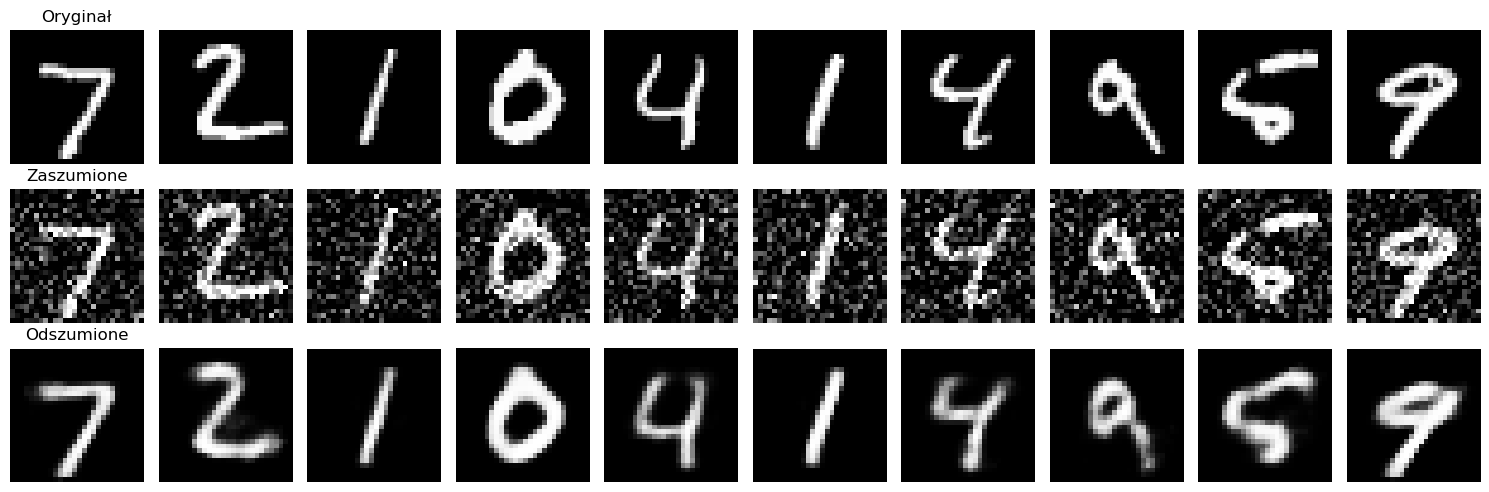

In [13]:
# =====================================================================
# ROZWIĄZANIE 4: Ewaluacja i Wizualizacja
# =====================================================================
model.eval()

# Pobieramy jedną paczkę danych testowych
test_data, _ = next(iter(test_loader))
clean_test_images = test_data.to(DEVICE)

# Tworzymy zaszumione wersje do testów
noisy_test_images = add_noise(clean_test_images, noise_factor=0.3)

with torch.no_grad():
    # Przepuszczamy zaszumione obrazy przez wytrenowany model
    reconstructed_images = model(noisy_test_images)

# --- WIZUALIZACJA ---
clean_test_images = clean_test_images.cpu().view(-1, 28, 28).numpy()
noisy_test_images = noisy_test_images.cpu().view(-1, 28, 28).numpy()
reconstructed_images = reconstructed_images.cpu().view(-1, 28, 28).numpy()

fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(15, 5))
for i in range(10):
    # Rząd 1: Oryginał
    axes[0, i].imshow(clean_test_images[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Oryginał")
        
    # Rząd 2: Zaszumione
    axes[1, i].imshow(noisy_test_images[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Zaszumione")
        
    # Rząd 3: Rekonstrukcja
    axes[2, i].imshow(reconstructed_images[i], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Odszumione")

plt.tight_layout()
plt.show()